<a href="https://colab.research.google.com/github/23064088/DataMiningGroup18/blob/combine_final/final_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# --- INSTALLATIONS ---
!pip install Faker transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.6 MB/s eta 0:00:00


In [3]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
from faker import Faker
import random
from transformers import pipeline, set_seed

In [4]:
# ==========================================
# 🟢 STEP 1: SETUP GenAI MODEL
# ==========================================
print("⏳ Loading AI Model (DistilGPT-2)... please wait...")
# We use a small model from Hugging Face
generator = pipeline('text-generation', model='distilgpt2')
set_seed(42)

def generate_text_batch(prompt_start, count=20):
    """Generates a list of unique sentences using the AI model."""
    print(f"   ...Generating {count} variations for prompt: '{prompt_start}'")

    generated_list = []
    for _ in range(count):
        # Parameters to make text creative and diverse
        result = generator(
            prompt_start,
            max_length=30,
            num_return_sequences=1,
            do_sample=True,
            temperature=0.9, # High creativity
            truncation=True
        )
        # Clean up text (remove newlines)
        text = result[0]['generated_text'].replace("\n", " ")
        generated_list.append(text)
    return generated_list

⏳ Loading AI Model (DistilGPT-2)... please wait...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0


In [5]:
# ==========================================
# 🟢 STEP 2: GENERATE THE CORPUS
# ==========================================
print("🚀 Starting AI Text Generation (Batch Mode)...")

# Generate 30 unique examples for each category to use in the dataset
risky_corpus_ai = generate_text_batch("I am writing to report financial difficulties because", count=30)
safe_corpus_ai = generate_text_batch("I want to invest my savings in", count=30)

print(f"✅ AI Corpus Ready! ({len(risky_corpus_ai)} risky, {len(safe_corpus_ai)} safe sentences)")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🚀 Starting AI Text Generation (Batch Mode)...
   ...Generating 30 variations for prompt: 'I am writing to report financial difficulties because'


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_

   ...Generating 30 variations for prompt: 'I want to invest my savings in'


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_

✅ AI Corpus Ready! (30 risky, 30 safe sentences)


In [6]:
len(risky_corpus_ai), len(safe_corpus_ai)

(30, 30)

In [7]:
print("🔴 Risky Corpus:")
for i, text in enumerate(risky_corpus_ai, start=1):
    print(f"{i}. {text}")

print("\n🟢 Safe Corpus:")
for i, text in enumerate(safe_corpus_ai, start=1):
    print(f"{i}. {text}")

🔴 Risky Corpus:
1. I am writing to report financial difficulties because of the problems that have been caused, and to have the benefit of making it hard for you to start the business.›   I am very happy, and also very happy that we are now able to see what is happening here. I hope to report that there are more and more opportunities. I appreciate that everyone has a plan and we should be able to work together, in many cases in many cases. In some cases I› hope that all the money that we have made here will be used to build more real estate, more affordable housing, more access to health and safety, more affordable housing and more jobs. In the meantime, I am very happy that we are now able to see how you are coping with the problems that are happening here, but to have the benefit of making it hard for you to start the business. Thank you for visiting me.
2. I am writing to report financial difficulties because there are some people who have some degree of disability but they can't w

In [8]:
# ==========================================
# 🟢 STEP 3: MAIN SIMULATION(Original Logic)
# ==========================================

# --- AI Text Function (Now uses the Real AI Corpus) ---
def generate_ai_text(is_risky):
    # Instead of hardcoded strings, we pick from the AI-generated list
    if is_risky:
        return random.choice(risky_corpus_ai)
    else:
        return random.choice(safe_corpus_ai)

In [9]:
# --- SEEDS ---
Faker.seed(42)
np.random.seed(42)
random.seed(42)

In [10]:
# --- PARAMETERS ---
NUM_SAMPLES = 2000
data = []

print("🚀 Starting Data Simulation Loop...")

for i in range(NUM_SAMPLES):
    if i % 200 == 0:
        print(f"Generating row {i} / {NUM_SAMPLES}...")

    # --- A. BASIC FEATURES ---
    fake = Faker()
    id_num = fake.uuid4()
    age = np.random.randint(21, 70)
    monthly_income = np.random.randint(2500, 12000)  # in RM
    loan_amount = np.random.randint(5000, 50000)
    interest_rate = np.random.uniform(5.0, 25.0)
    debt_to_income_ratio = loan_amount / monthly_income

    # Credit score correlated with income, noisy
    base_score = 600 + monthly_income / 100
    credit_score = int(np.random.normal(base_score, 50))
    credit_score = max(300, min(850, credit_score))

    # Late payment count
    late_payment_count_12m = np.random.poisson(1)

    # Financial confidence category
    financial_confidence = random.choices(
        ["Low", "Medium", "High"], weights=[0.3, 0.5, 0.2]
    )[0]

    # Bank type
    bank_type = random.choices(["Traditional", "Digital"], weights=[0.6, 0.4])[0]

    # Risk keywords present (binary)
    risk_keywords_present = np.random.binomial(1, 0.3)

    # --- B. PROBABILISTIC RISK SCORE ---
    prob_risk = 0.05
    prob_risk += 0.4 / (1 + np.exp((credit_score - 620)/20))
    prob_risk += 0.35 / (1 + np.exp((30 - debt_to_income_ratio*10)))
    prob_risk += 0.2 / (1 + np.exp((monthly_income - 5000)/2000))
    prob_risk += 0.1 * (interest_rate/25)
    prob_risk += 0.05 * late_payment_count_12m
    prob_risk += 0.05 * risk_keywords_present
    prob_risk += np.random.uniform(-0.1, 0.1)
    prob_risk = max(0, min(1, prob_risk))

    # --- C. LOAN DEFAULT ---
    loan_default = 1 if np.random.rand() < prob_risk else 0

    # --- D. RISK FLAG ---
    if prob_risk < 0.33:
        risk_flag = 0
    elif prob_risk < 0.66:
        risk_flag = 1
    else:
        risk_flag = 2

    # --- E. AI TEXT WITH LYING FACTOR (Uses the new function) ---
    lying_factor = 0.15
    use_risky_text = risk_flag == 2
    if np.random.rand() < lying_factor:
        use_risky_text = not use_risky_text

    customer_statement = generate_ai_text(is_risky=use_risky_text)

    # --- F. APPEND ROW ---
    data.append([
        id_num, age, monthly_income, credit_score, loan_amount, interest_rate,
        debt_to_income_ratio, late_payment_count_12m, financial_confidence,
        bank_type, risk_keywords_present, customer_statement, loan_default, risk_flag
    ])

# --- G. CREATE DATAFRAME ---
columns = [
    "id_num", "age", "monthly_income", "credit_score", "loan_amount",
    "interest_rate", "debt_to_income_ratio", "late_payment_count_12m",
    "financial_confidence", "bank_type", "risk_keywords_present",
    "customer_statement", "loan_default", "risk_flag"
]

🚀 Starting Data Simulation Loop...
Generating row 0 / 2000...
Generating row 200 / 2000...
Generating row 400 / 2000...
Generating row 600 / 2000...
Generating row 800 / 2000...
Generating row 1000 / 2000...
Generating row 1200 / 2000...
Generating row 1400 / 2000...
Generating row 1600 / 2000...
Generating row 1800 / 2000...


In [11]:
df_new = pd.DataFrame(data, columns=columns)

In [12]:
df_new.head()

,id_num,age,monthly_income,credit_score,loan_amount,interest_rate,debt_to_income_ratio,late_payment_count_12m,financial_confidence,bank_type,risk_keywords_present,customer_statement,loan_default,risk_flag
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,59,3360,578,43158,19.639879,12.844643,0,Medium,Traditional,0,I am writing to report financial difficulties ...,1,2
1,23b8c1e9-3924-46de-beb1-3b9046685257,42,3269,648,7433,8.636499,2.273784,0,Low,Traditional,0,I want to invest my savings in the very moment...,0,0
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,62,4547,718,7747,12.327237,1.703761,0,Medium,Digital,0,I want to invest my savings in the next year. ...,1,0
3,972a8469-1641-4f82-8b9d-2434e465e150,41,7893,667,15627,23.844035,1.979856,1,Medium,Traditional,0,I want to invest my savings in the next year. ...,0,0
4,17fc695a-07a0-4a6e-8822-e8f36c031199,64,3275,573,49974,8.467293,15.259237,1,Low,Traditional,0,I am writing to report financial difficulties ...,1,2


In [13]:
df_new.to_csv('Financial_Data_Latest.csv', index=False)
from google.colab import files
files.download('Financial_Data_Latest.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Sentiment Analysis

In [14]:
file_path = "/content/Financial_Data_Latest.csv"
df = pd.read_csv(file_path)

print("✅ Dataset loaded")
df.head()

✅ Dataset loaded


,id_num,age,monthly_income,credit_score,loan_amount,interest_rate,debt_to_income_ratio,late_payment_count_12m,financial_confidence,bank_type,risk_keywords_present,customer_statement,loan_default,risk_flag
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,59,3360,578,43158,19.639879,12.844643,0,Medium,Traditional,0,I am writing to report financial difficulties ...,1,2
1,23b8c1e9-3924-46de-beb1-3b9046685257,42,3269,648,7433,8.636499,2.273784,0,Low,Traditional,0,I want to invest my savings in the very moment...,0,0
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,62,4547,718,7747,12.327237,1.703761,0,Medium,Digital,0,I want to invest my savings in the next year. ...,1,0
3,972a8469-1641-4f82-8b9d-2434e465e150,41,7893,667,15627,23.844035,1.979856,1,Medium,Traditional,0,I want to invest my savings in the next year. ...,0,0
4,17fc695a-07a0-4a6e-8822-e8f36c031199,64,3275,573,49974,8.467293,15.259237,1,Low,Traditional,0,I am writing to report financial difficulties ...,1,2


#Feature Engineering

In [15]:
print("⏳ Loading FinBERT model...")
classifier = pipeline("sentiment-analysis", model="ProsusAI/finbert")
print("✅ FinBERT loaded")

⏳ Loading FinBERT model...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


✅ FinBERT loaded


In [16]:
def get_sentiment_score(text):
    # Make sure the input is a string and limit length for the model
    text = str(text)[:512]

    try:
        # Run FinBERT sentiment analysis on the text
        result = classifier(text)[0]

        # If sentiment is negative, return the confidence score (higher = more negative)
        if result['label'] == 'negative':
            return result['score']

        # If sentiment is positive, invert the score (lower risk signal)
        elif result['label'] == 'positive':
            return 1 - result['score']

        # Neutral sentiment gets a middle value
        else:
            return 0.5

    # If anything goes wrong, return neutral score
    except:
        return 0.5

In [17]:
# Apply sentiment scoring to each customer statement
df['Sentiment_Score'] = df['customer_statement'].apply(get_sentiment_score)

# Quick check
df[['customer_statement', 'Sentiment_Score']].head()


,customer_statement,Sentiment_Score
0,I am writing to report financial difficulties ...,0.500000
1,I want to invest my savings in the very moment...,0.500000
2,I want to invest my savings in the next year. ...,0.500000
3,I want to invest my savings in the next year. ...,0.500000
4,I am writing to report financial difficulties ...,0.313378


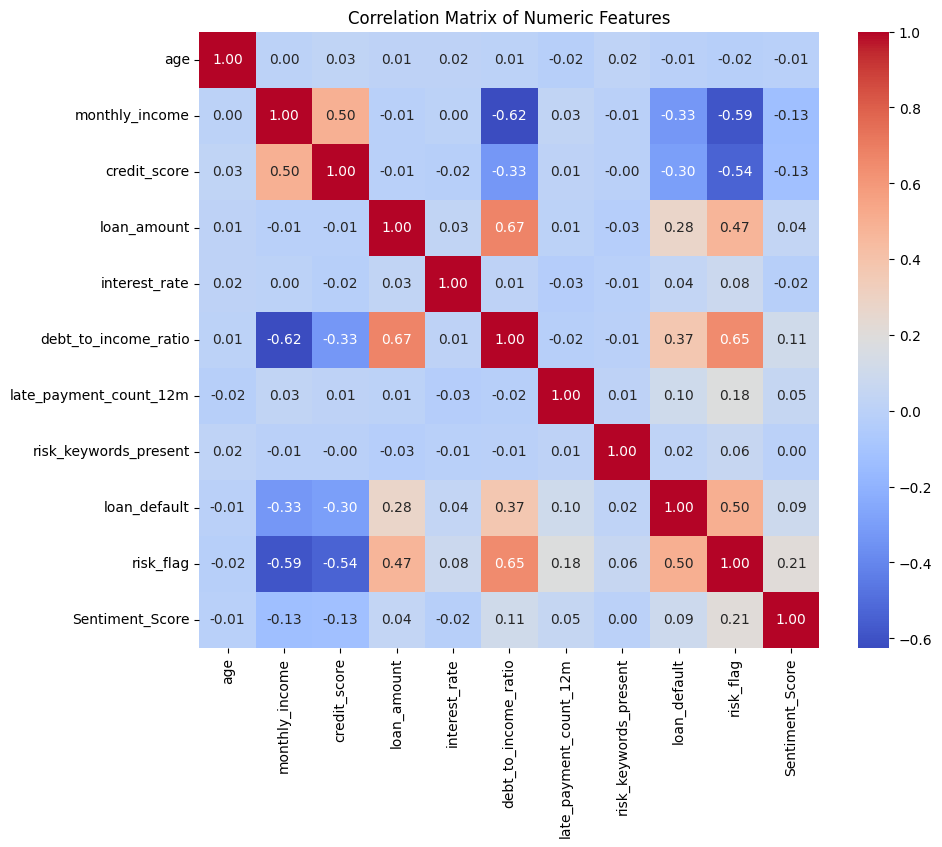


Correlation values for Sentiment_Score:
Sentiment_Score           1.000000
risk_flag                 0.209141
debt_to_income_ratio      0.107996
loan_default              0.087405
late_payment_count_12m    0.054434
loan_amount               0.036520
risk_keywords_present     0.002929
age                      -0.009748
interest_rate            -0.016626
credit_score             -0.127973
monthly_income           -0.132214
Name: Sentiment_Score, dtype: float64


In [18]:
# Check correlation

import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Display heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Numeric Features")
plt.show()

# Optional: quick numeric check
print("\nCorrelation values for Sentiment_Score:")
print(corr_matrix['Sentiment_Score'].sort_values(ascending=False))

In [19]:
# Save the dataset with sentiment column added
output_path = "/content/Financial_Data_New_With_Sentiment.csv"
df.to_csv(output_path, index=False)

print(f"✅ Sentiment analysis complete. New dataset saved as: {output_path}")

✅ Sentiment analysis complete. New dataset saved as: /content/Financial_Data_New_With_Sentiment.csv


#EDA

In [41]:
prompt = f"""you are a data analyst interpreting a correlation matrix from a credit risk dataset.

The correlation matrix below show Pearson correlation coefficients
between numerical features

{corr_matrix.round(2).to_string()}

Task:
-Identify notable positive and negative correlations
-Explain what these relationship may indicate
-Comment on potential multicollinearity or redundancy
-keep explanation simple and concise

Answer:

"""
# Generate (better settings for "answer style")
result = generator(
    prompt,
    max_new_tokens=140,        # better than max_length (doesn't count prompt tokens)
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.15,
    truncation=True
)

# Extract and clean output
raw_text = result[0]["generated_text"]
answer = raw_text.split("Answer:")[-1].strip()

print("📌 LLM Interpretation Output:\n")
print(answer)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
This is a friendly reminder - the current text generation call has exceeded the model's predefined maximum length (1024). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.


📌 LLM Interpretation Output:




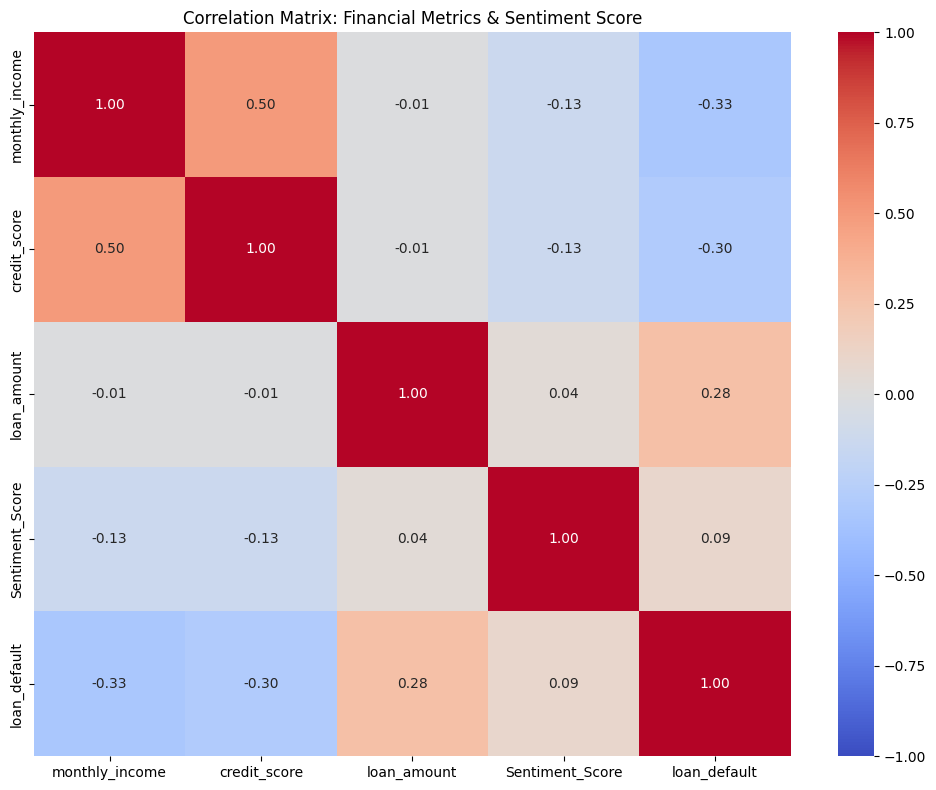

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select relevant numerical columns
columns = [
    "monthly_income",
    "credit_score",
    "loan_amount",
    "Sentiment_Score",
    "loan_default"
]

correlation_matrix = df[columns].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix: Financial Metrics & Sentiment Score")
plt.tight_layout()
plt.show()

In [40]:
prompt = f"""you are a data analyst evaluating the relationship between traditional numerical financial variables and LLM-derived feature scores in a credit default dataset.

The correlation matrix below includes:
- monthly_income
- credit_score
- loan_amount
- sentiment_score

Correlation matrix:
{correlation_matrix.round(2).to_string()}

Task:
- Explain how LLM-derived scores relate to traditional financial variables
- Identify whether these scores align with expected risk patterns
- Comment on their potential usefulness for credit risk modelling
- Keep explanation simple and concise

Answer:
"""

##Modelling

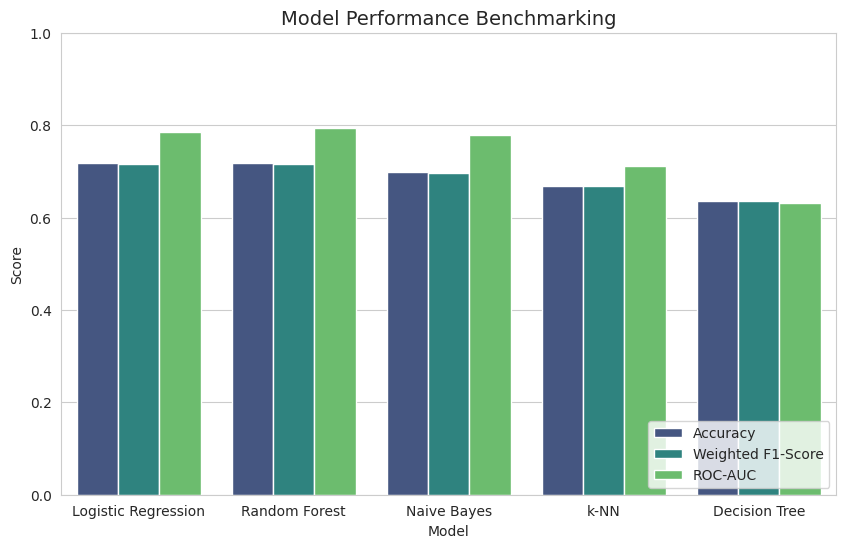

/tmp/ipython-input-1341280818.py:121: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--')


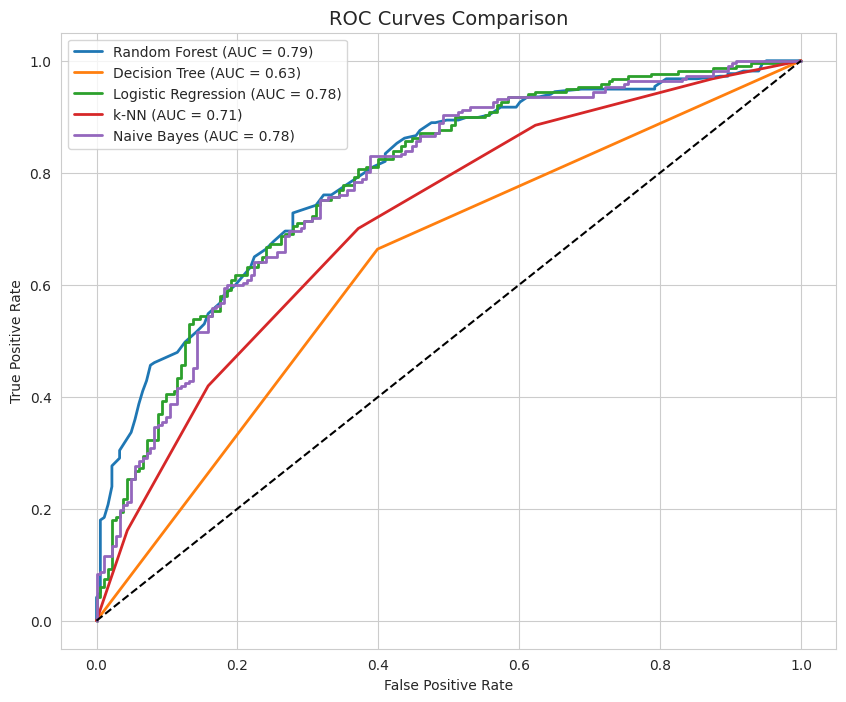

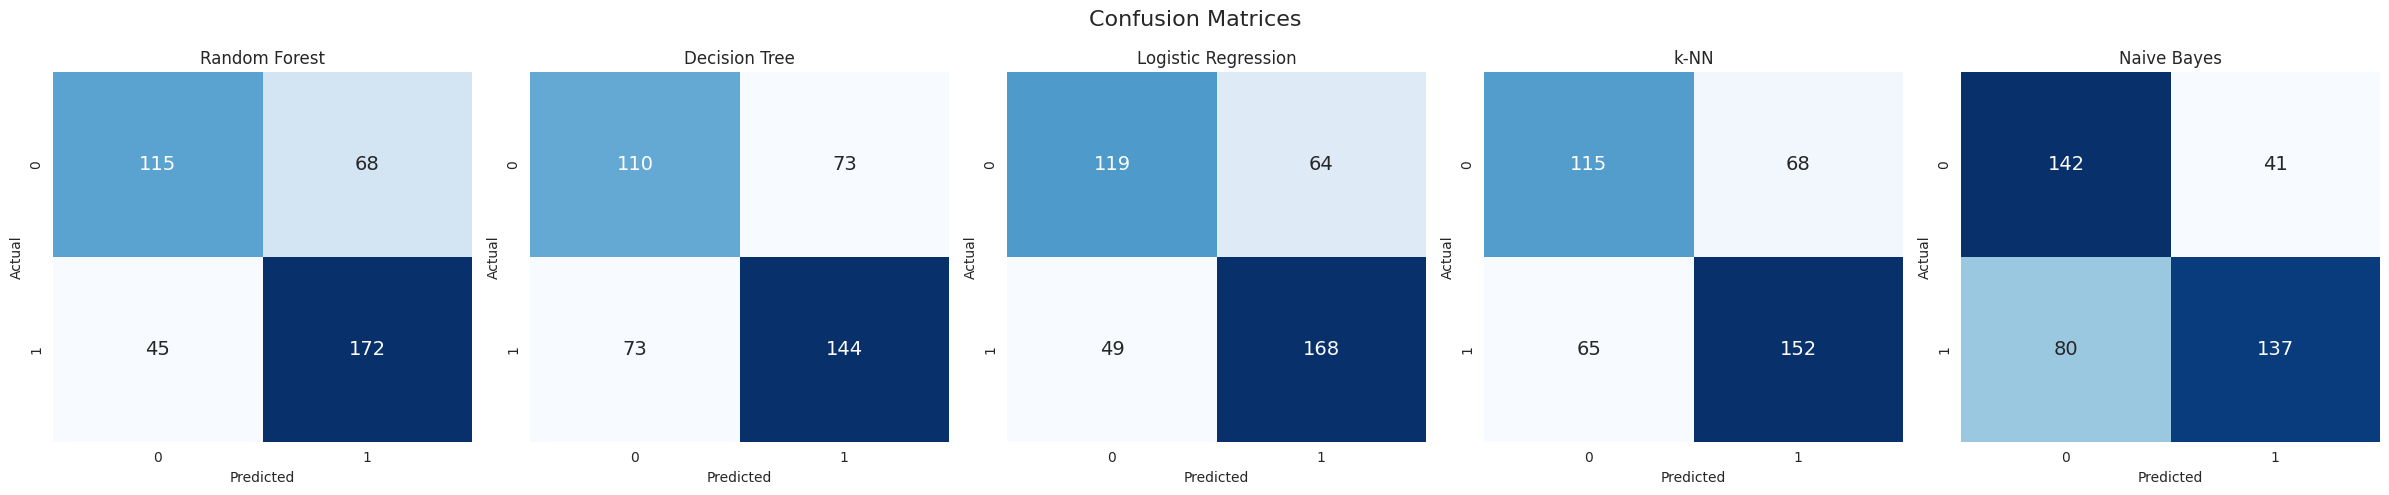

/tmp/ipython-input-1341280818.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="magma")


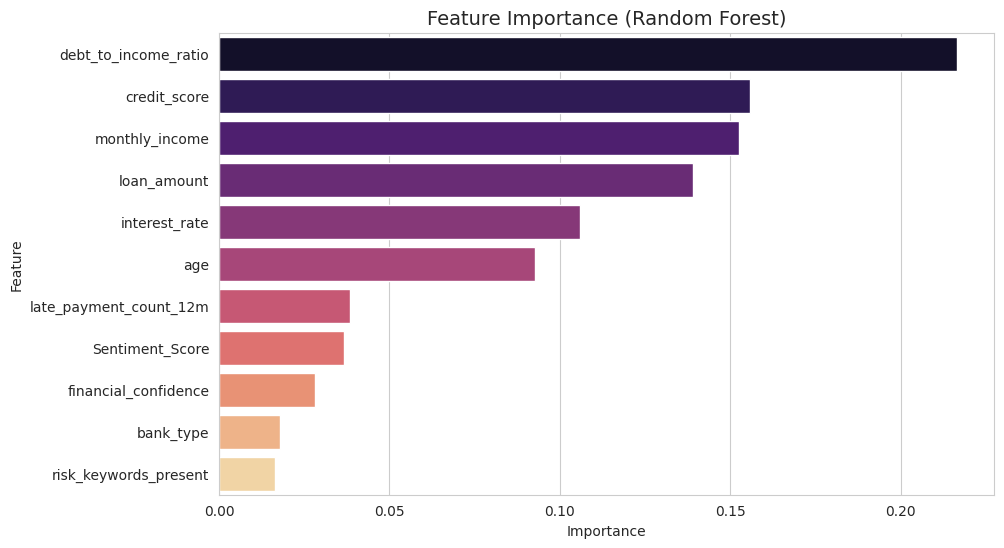

Model Leaderboard:
                 Model  Accuracy  Weighted F1-Score   ROC-AUC
2  Logistic Regression    0.7175           0.716182  0.784392
0        Random Forest    0.7175           0.715137  0.794201
4          Naive Bayes    0.6975           0.697131  0.778248
3                 k-NN    0.6675           0.667267  0.711893
1        Decision Tree    0.6350           0.635000  0.632344

Top Features:
                Feature  Importance
5  debt_to_income_ratio    0.216552
2          credit_score    0.155645
1        monthly_income    0.152614
3           loan_amount    0.139059
4         interest_rate    0.105770


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# 1. Load Data
# Upload your file to Colab files section and use the correct path
file_path = 'Financial_Data_New_With_Sentiment.csv'
df = pd.read_csv(file_path)

# 2. Preprocessing
data = df.copy()

# Drop identifiers and text columns not used for baseline modeling
# We drop 'risk_flag' to focus on 'loan_default' as the primary binary target
data = data.drop(columns=['id_num', 'customer_statement', 'risk_flag'])

# Encode Categorical Variables
# Ordinal encoding for financial_confidence
confidence_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['financial_confidence'] = data['financial_confidence'].map(confidence_mapping)

# Binary encoding for bank_type
data['bank_type'] = data['bank_type'].apply(lambda x: 1 if x == 'Digital' else 0)

# Define Features (X) and Target (y)
X = data.drop(columns=['loan_default'])
y = data['loan_default']

# 80/20 Train-Test split with Stratified Sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (Critical for Logistic Regression and k-NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model Initialization
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "k-NN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

# 4. Training & Evaluation Loop
results = []
roc_curves = {}
confusion_matrices = {}
feature_importance = None

for name, model in models.items():
    # Use scaled data for distance/linear based models
    if name in ["Logistic Regression", "k-NN", "Naive Bayes"]:
        curr_X_train, curr_X_test = X_train_scaled, X_test_scaled
    else:
        curr_X_train, curr_X_test = X_train, X_test

    # Train
    model.fit(curr_X_train, y_train)

    # Predict
    y_pred = model.predict(curr_X_test)
    y_prob = model.predict_proba(curr_X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Weighted F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    # Store for plotting
    roc_curves[name] = (y_test, y_prob)
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

    # Extract Feature Importance from Random Forest
    if name == "Random Forest":
        feature_importance = pd.DataFrame({
            'Feature': X.columns,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False)

# Create Results DataFrame
results_df = pd.DataFrame(results).sort_values(by='Weighted F1-Score', ascending=False)

# 5. Visualizations

# Set Plot Style
sns.set_style("whitegrid")

# A. Model Performance Comparison Bar Chart
plt.figure(figsize=(10, 6))
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title("Model Performance Benchmarking", fontsize=14)
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

# B. ROC Curves
plt.figure(figsize=(10, 8))
for name, (y_true, y_score) in roc_curves.items():
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_score = results_df[results_df["Model"]==name]["ROC-AUC"].values[0]
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison', fontsize=14)
plt.legend()
plt.show()

# C. Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, annot_kws={"size": 14})
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle("Confusion Matrices", fontsize=16)
plt.tight_layout()
plt.show()

# D. Feature Importance (Random Forest)
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="magma")
plt.title("Feature Importance (Random Forest)", fontsize=14)
plt.show()

# Print Numerical Results
print("Model Leaderboard:")
print(results_df)
print("\nTop Features:")
print(feature_importance.head())

##Feature Importance

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

champ = models["Logistic Regression"]
preds = champ.predict(X_test)
proba = champ.predict_proba(X_test)[:,1]

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("Default rate:", y.mean())

[[ 15 168]
 [  2 215]]
              precision    recall  f1-score   support

           0       0.88      0.08      0.15       183
           1       0.56      0.99      0.72       217

    accuracy                           0.57       400
   macro avg       0.72      0.54      0.43       400
weighted avg       0.71      0.57      0.46       400

ROC-AUC: 0.5362494019289366
Default rate: 0.5415


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [31]:
from sklearn.inspection import permutation_importance

importance_matrix = pd.DataFrame(index=X.columns)

for name, m in models.items():
    # For models that were trained on scaled data, X_test_scaled should be used.
    # For models trained on unscaled data (like Decision Tree and Random Forest),
    # the original X_test should be used.
    if name in ["Logistic Regression", "k-NN", "Naive Bayes"]:
        curr_X_test_perm = X_test_scaled
    else:
        curr_X_test_perm = X_test

    perm = permutation_importance(
        m, curr_X_test_perm, y_test,
        n_repeats=15,
        random_state=42,
        scoring="f1_weighted"
    )
    importance_matrix[name] = perm.importances_mean

# sort by champion (Random Forest) importance
importance_matrix = importance_matrix.sort_values(by="Random Forest", ascending=False)

importance_matrix

,Random Forest,Decision Tree,Logistic Regression,k-NN,Naive Bayes
debt_to_income_ratio,0.093766,0.112771,0.005214,0.031832,0.032971
credit_score,0.018145,0.047420,0.031644,0.019762,0.020816
monthly_income,0.014735,0.016999,0.094903,0.045984,0.025709
loan_amount,0.012892,0.014243,0.111059,0.051002,0.016424
interest_rate,0.001849,0.011164,-0.001064,0.017472,0.003808
late_payment_count_12m,-0.002392,-0.002162,0.016778,-0.002321,0.005964
bank_type,-0.004680,-0.004891,-0.000250,-0.018016,-0.000861
Sentiment_Score,-0.004922,0.009941,0.000193,0.001920,-0.007523
financial_confidence,-0.007077,-0.001937,-0.006268,-0.001751,-0.006856
age,-0.011591,-0.021181,-0.001859,-0.007286,0.002922


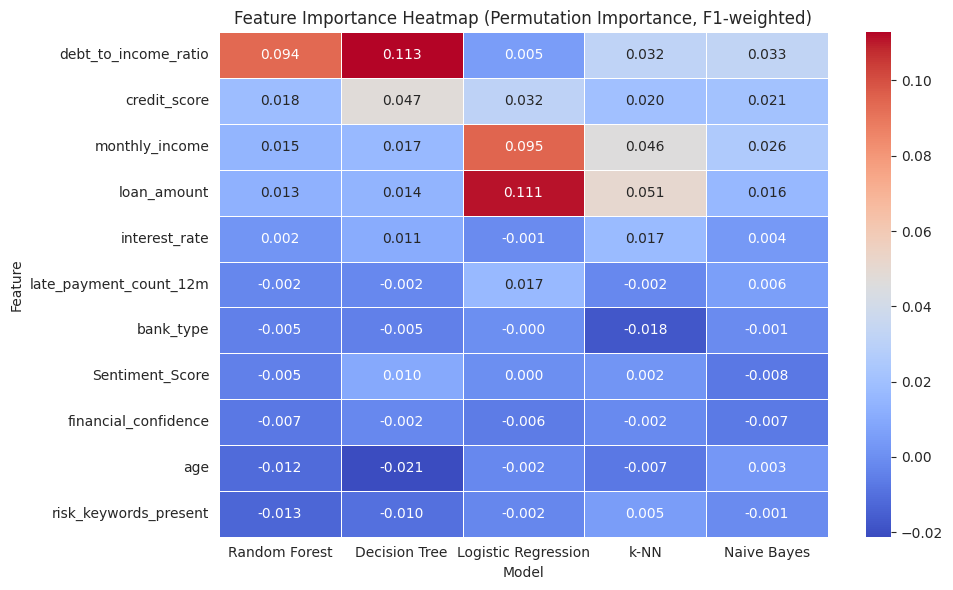

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# make height scale with number of features
n_features = importance_matrix.shape[0]
plt.figure(figsize=(10, max(6, n_features * 0.35)))  # adjust 0.35 if needed

sns.heatmap(
    importance_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Importance Heatmap (Permutation Importance, F1-weighted)")
plt.ylabel("Feature")
plt.xlabel("Model")
plt.tight_layout()
plt.savefig("feature_importance_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()



               Feature     Score
  debt_to_income_ratio  0.093766
          credit_score  0.018145
        monthly_income  0.014735
           loan_amount  0.012892
         interest_rate  0.001849
late_payment_count_12m -0.002392
             bank_type -0.004680
       Sentiment_Score -0.004922
  financial_confidence -0.007077
                   age -0.011591


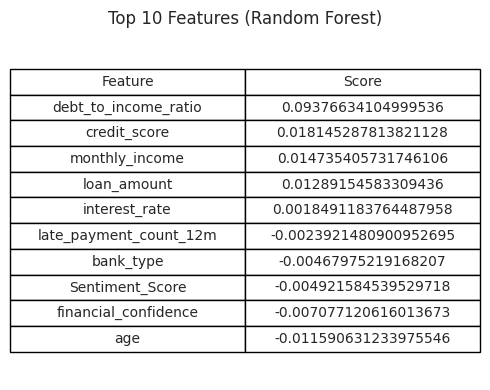

✅ Saved: rf_top10_table.png


In [33]:
topN = 10

rf_top = (importance_matrix["Random Forest"]
          .sort_values(ascending=False)
          .head(topN)
          .reset_index())

rf_top.columns = ["Feature", "Score"]
print(rf_top.to_string(index=False))

# save as a clean table image
fig, ax = plt.subplots(figsize=(5, 4))
ax.axis("off")

table = ax.table(
    cellText=rf_top.values,
    colLabels=rf_top.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

plt.title("Top 10 Features (Random Forest)", pad=12)
plt.tight_layout()
plt.savefig("rf_top10_table.png", dpi=300)
plt.show()

print("✅ Saved: rf_top10_table.png")
